In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/manifest.safe
/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/INSPIRE.xml
/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/MTD_MSIL2A.xml
/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619-ql.jpg
/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/DATASTRIP/DS_2BPS_20260826T091619_S20260826T053640/MTD_DS.xml
/kaggle/input/datasets/nakulhemantkarpe/sentinel-2-l2a/S2B_MSIL2A_20260826T052639_N0512_R105_T43QCC_20260826T091619.SAFE/DATASTRIP/DS_2BPS_20260826T091619_S20260826T053640/QI_DATA/RADIOMETRIC_QUALITY.xml
/kaggle/input/datase

In [14]:
!pip -q install tacoreader rasterio

In [15]:
!pip install -q "tacoreader<1.0"

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import torch

print(torch.__version__)
print(torch.__file__)
print(torch.cuda.is_available())

from skimage.metrics import structural_similarity as ssim

print("Imports OK")
print("GPU:", torch.cuda.is_available())

2.10.0+cu128
/usr/local/lib/python3.12/dist-packages/torch/__init__.py
True
Imports OK
GPU: True


LR: (4, 64, 64)
HR: (4, 256, 256)


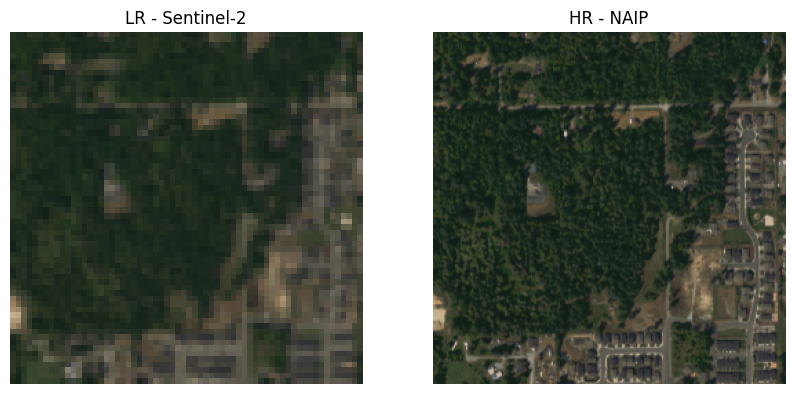

In [17]:
import tacoreader
import rasterio as rio
import matplotlib.pyplot as plt

dataset = tacoreader.load("tacofoundation:sen2naipv2-unet")

sample_idx = 4000

lr = dataset.read(sample_idx).read(0)
hr = dataset.read(sample_idx).read(1)

with rio.open(lr) as src, rio.open(hr) as dst:
    lr_data = src.read(
        window=rio.windows.Window(0, 0, 64, 64)
    )
    hr_data = dst.read(
        window=rio.windows.Window(0, 0, 256, 256)
    )

print("LR:", lr_data.shape)
print("HR:", hr_data.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(lr_data[:3].transpose(1, 2, 0) / 3000)
ax[0].set_title("LR - Sentinel-2")
ax[0].axis("off")

ax[1].imshow(hr_data[:3].transpose(1, 2, 0) / 3000)
ax[1].set_title("HR - NAIP")
ax[1].axis("off")

plt.show()

In [18]:
train_pairs = []

NUM_TRAIN = 100

for i in range(NUM_TRAIN):

    lr_path = dataset.read(i).read(0)
    hr_path = dataset.read(i).read(1)

    with rio.open(lr_path) as src:
        lr = src.read().astype("float32")

    with rio.open(hr_path) as src:
        hr = src.read().astype("float32")

    # Same normalization used in our previous experiment
    lr = lr / 3000.0
    hr = hr / 3000.0

    train_pairs.append((lr, hr))

    if (i + 1) % 20 == 0:
        print(f"Loaded {i+1}/{NUM_TRAIN}")

print("Done.")
print(train_pairs[0][0].shape)
print(train_pairs[0][1].shape)

Loaded 20/100
Loaded 40/100
Loaded 60/100
Loaded 80/100
Loaded 100/100
Done.
(4, 130, 130)
(4, 520, 520)


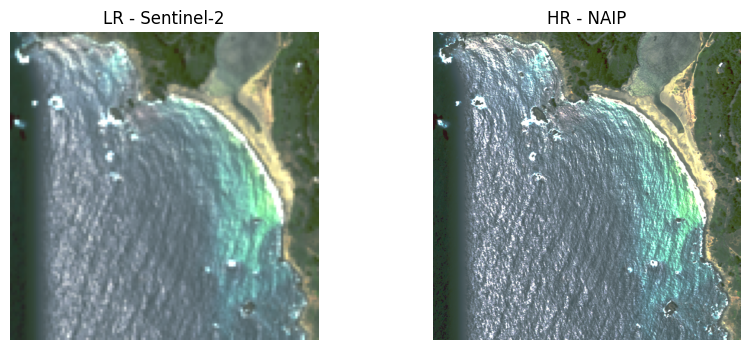

In [19]:
lr, hr = train_pairs[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.clip(lr[:3].transpose(1, 2, 0) * 2, 0, 1))
plt.title("LR - Sentinel-2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(hr[:3].transpose(1, 2, 0) * 2, 0, 1))
plt.title("HR - NAIP")
plt.axis("off")

plt.show()

In [20]:
def make_patch(lr, hr, patch_size=32):

    lr_h, lr_w = lr.shape[1:]

    y = np.random.randint(
        0,
        lr_h - patch_size + 1
    )

    x = np.random.randint(
        0,
        lr_w - patch_size + 1
    )

    lr_patch = lr[
        :,
        y:y+patch_size,
        x:x+patch_size
    ]

    hr_y = y * 4
    hr_x = x * 4

    hr_patch = hr[
        :,
        hr_y:hr_y + patch_size*4,
        hr_x:hr_x + patch_size*4
    ]

    return lr_patch, hr_patch

In [21]:
lr_patch, hr_patch = make_patch(
    train_pairs[0][0],
    train_pairs[0][1]
)

print("LR patch:", lr_patch.shape)
print("HR patch:", hr_patch.shape)

LR patch: (4, 32, 32)
HR patch: (4, 128, 128)


In [22]:
class RCAB(nn.Module):

    def __init__(self, channels=96, reduction=8):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.attention = nn.Sequential(
            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                channels // reduction,
                channels,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        residual = x

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        # Channel attention
        weights = self.avg_pool(out)
        weights = self.attention(weights)

        out = out * weights

        # Residual scaling
        out = out * 0.1

        # Skip connection
        out = out + residual

        return out

In [26]:
class RCAN(nn.Module):

    def __init__(
        self,
        num_blocks=12,
        channels=96
    ):
        super().__init__()

        # 4-band Sentinel-2 input
        self.head = nn.Conv2d(
            4,
            channels,
            3,
            padding=1
        )

        # 12 RCABs
        self.body = nn.Sequential(
            *[
                RCAB(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        # 2x upsampling
        self.up1 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        # another 2x = total 4x
        self.up2 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        # 4-band RGBN output
        self.tail = nn.Conv2d(
            channels,
            4,
            3,
            padding=1
        )

    def forward(self, x):

        # Initial feature extraction
        features = self.head(x)

        # Global residual
        residual = features

        # RCAB stack
        features = self.body(features)

        features = self.body_conv(features)

        # Global residual connection
        features = features + residual

        # 4x upsampling
        features = self.up1(features)
        features = self.up2(features)

        # Reconstruction
        output = self.tail(features)

        return output

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = RCAN(
    num_blocks=12,
    channels=96
).to(device)

print("Device:", device)

print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

Device: cuda
Parameters: 2776276


In [28]:
model = RCAN(
    num_blocks=12,
    channels=96
).to(device)

print("Model ready")
print("Device:", device)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Model ready
Device: cuda
Parameters: 2776276


In [29]:
lr_patch, hr_patch = make_patch(
    train_pairs[0][0],
    train_pairs[0][1]
)

lr_tensor = torch.tensor(
    lr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

hr_tensor = torch.tensor(
    hr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(lr_tensor)

print("Input :", lr_tensor.shape)
print("Output:", output.shape)
print("Target:", hr_tensor.shape)

Input : torch.Size([1, 4, 32, 32])
Output: torch.Size([1, 4, 128, 128])
Target: torch.Size([1, 4, 128, 128])


In [30]:
lr_patch, hr_patch = make_patch(
    train_pairs[0][0],
    train_pairs[0][1]
)

lr_tensor = torch.tensor(
    lr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

hr_tensor = torch.tensor(
    hr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    test_output = model(
        lr_tensor
    )

print("Input :", lr_tensor.shape)
print("Output:", test_output.shape)
print("Target:", hr_tensor.shape)

Input : torch.Size([1, 4, 32, 32])
Output: torch.Size([1, 4, 128, 128])
Target: torch.Size([1, 4, 128, 128])


In [34]:
class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon=1e-3):

        super().__init__()

        self.epsilon = epsilon

    def forward(self, prediction, target):

        difference = prediction - target

        loss = torch.sqrt(
            difference ** 2 +
            self.epsilon ** 2
        )

        return loss.mean()


loss_fn = CharbonnierLoss()

In [35]:
def gradient_loss(pred, target):

    # Horizontal gradients
    pred_x = (
        pred[:, :, :, 1:]
        -
        pred[:, :, :, :-1]
    )

    target_x = (
        target[:, :, :, 1:]
        -
        target[:, :, :, :-1]
    )

    # Vertical gradients
    pred_y = (
        pred[:, :, 1:, :]
        -
        pred[:, :, :-1, :]
    )

    target_y = (
        target[:, :, 1:, :]
        -
        target[:, :, :-1, :]
    )

    loss_x = torch.mean(
        torch.abs(
            pred_x - target_x
        )
    )

    loss_y = torch.mean(
        torch.abs(
            pred_y - target_y
        )
    )

    return loss_x + loss_y

In [37]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer ready")

Optimizer ready


In [38]:
EPOCHS = 20
PATCHES_PER_EPOCH = 200

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for step in range(PATCHES_PER_EPOCH):

        # Pick random training image
        idx = np.random.randint(len(train_pairs))

        lr, hr = train_pairs[idx]

        # Random corresponding patches
        lr_patch, hr_patch = make_patch(lr, hr)

        lr_tensor = torch.tensor(
            lr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        hr_tensor = torch.tensor(
            hr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        # Forward pass
        prediction = model(lr_tensor)

        # Calculate loss
        loss = loss_fn(prediction, hr_tensor)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / PATCHES_PER_EPOCH

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.5f}"
    )

Epoch 1/20 | Loss: 0.09109
Epoch 2/20 | Loss: 0.05491
Epoch 3/20 | Loss: 0.04923
Epoch 4/20 | Loss: 0.04770
Epoch 5/20 | Loss: 0.04350
Epoch 6/20 | Loss: 0.04246
Epoch 7/20 | Loss: 0.04193
Epoch 8/20 | Loss: 0.04265
Epoch 9/20 | Loss: 0.04198
Epoch 10/20 | Loss: 0.04029
Epoch 11/20 | Loss: 0.03966
Epoch 12/20 | Loss: 0.04092
Epoch 13/20 | Loss: 0.03791
Epoch 14/20 | Loss: 0.03802
Epoch 15/20 | Loss: 0.03809
Epoch 16/20 | Loss: 0.03773
Epoch 17/20 | Loss: 0.03937
Epoch 18/20 | Loss: 0.03995
Epoch 19/20 | Loss: 0.03634
Epoch 20/20 | Loss: 0.03785


In [39]:
model.eval()

lr, hr = train_pairs[0]

lr_tensor = torch.tensor(
    lr,
    dtype=torch.float32
).unsqueeze(0).to(device)

with torch.no_grad():
    sr = model(lr_tensor).clamp(0, 1)

print("LR:", lr_tensor.shape)
print("SR:", sr.shape)
print("HR:", hr.shape)

LR: torch.Size([1, 4, 130, 130])
SR: torch.Size([1, 4, 520, 520])
HR: (4, 520, 520)


In [44]:
val_pairs = []

for i in range(100, 120):

    lr_path = dataset.read(i).read(0)
    hr_path = dataset.read(i).read(1)

    with rio.open(lr_path) as src:
        lr = src.read().astype("float32")

    with rio.open(hr_path) as src:
        hr = src.read().astype("float32")

    lr = lr / 3000.0
    hr = hr / 3000.0

    val_pairs.append(
        (lr, hr)
    )

print(
    "Validation pairs:",
    len(val_pairs)
)

Validation pairs: 20


In [45]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for lr, hr in val_pairs:

        lr_tensor = torch.tensor(
            lr,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        prediction = model(
            lr_tensor
        )

        predictions.append(
            prediction.cpu().numpy()[0]
        )

        targets.append(hr)

predictions = np.stack(predictions)
targets = np.stack(targets)

print("Predictions:", predictions.shape)
print("Targets:", targets.shape)

Predictions: (20, 4, 520, 520)
Targets: (20, 4, 520, 520)


In [47]:
test_pairs = []

for i in range(120, 130):

    lr_path = dataset.read(i).read(0)
    hr_path = dataset.read(i).read(1)

    with rio.open(lr_path) as src:
        lr = src.read().astype("float32")

    with rio.open(hr_path) as src:
        hr = src.read().astype("float32")

    lr = lr / 3000.0
    hr = hr / 3000.0

    test_pairs.append((lr, hr))

print("Unseen test pairs:", len(test_pairs))
print("LR:", test_pairs[0][0].shape)
print("HR:", test_pairs[0][1].shape)

Unseen test pairs: 10
LR: (4, 130, 130)
HR: (4, 520, 520)


In [48]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for lr, hr in test_pairs:

        x = torch.tensor(
            lr,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        sr = model(x)

        predictions.append(
            sr.cpu().numpy()[0]
        )

        targets.append(hr)

predictions = np.stack(predictions)
targets = np.stack(targets)

print("Predictions:", predictions.shape)
print("Targets:", targets.shape)

Predictions: (10, 4, 520, 520)
Targets: (10, 4, 520, 520)


In [49]:
mse = np.mean(
    (predictions - targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1 / (mse + 1e-10)
)

ssim_scores = []

for i in range(len(targets)):

    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

print("\n========== UNSEEN SEN2NAIP ==========")
print(f"RMSE : {rmse:.5f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {np.mean(ssim_scores):.4f}")


========== UNSEEN SEN2NAIP ==========
RMSE : 0.05746
PSNR : 24.813 dB
SSIM : 0.6793


In [53]:
def stretch_rgb(img):
    rgb = img[:3].transpose(1, 2, 0)

    output = np.zeros_like(rgb)

    for c in range(3):
        low = np.percentile(rgb[:, :, c], 2)
        high = np.percentile(rgb[:, :, c], 98)

        output[:, :, c] = np.clip(
            (rgb[:, :, c] - low) /
            (high - low + 1e-8),
            0,
            1
        )

    return output

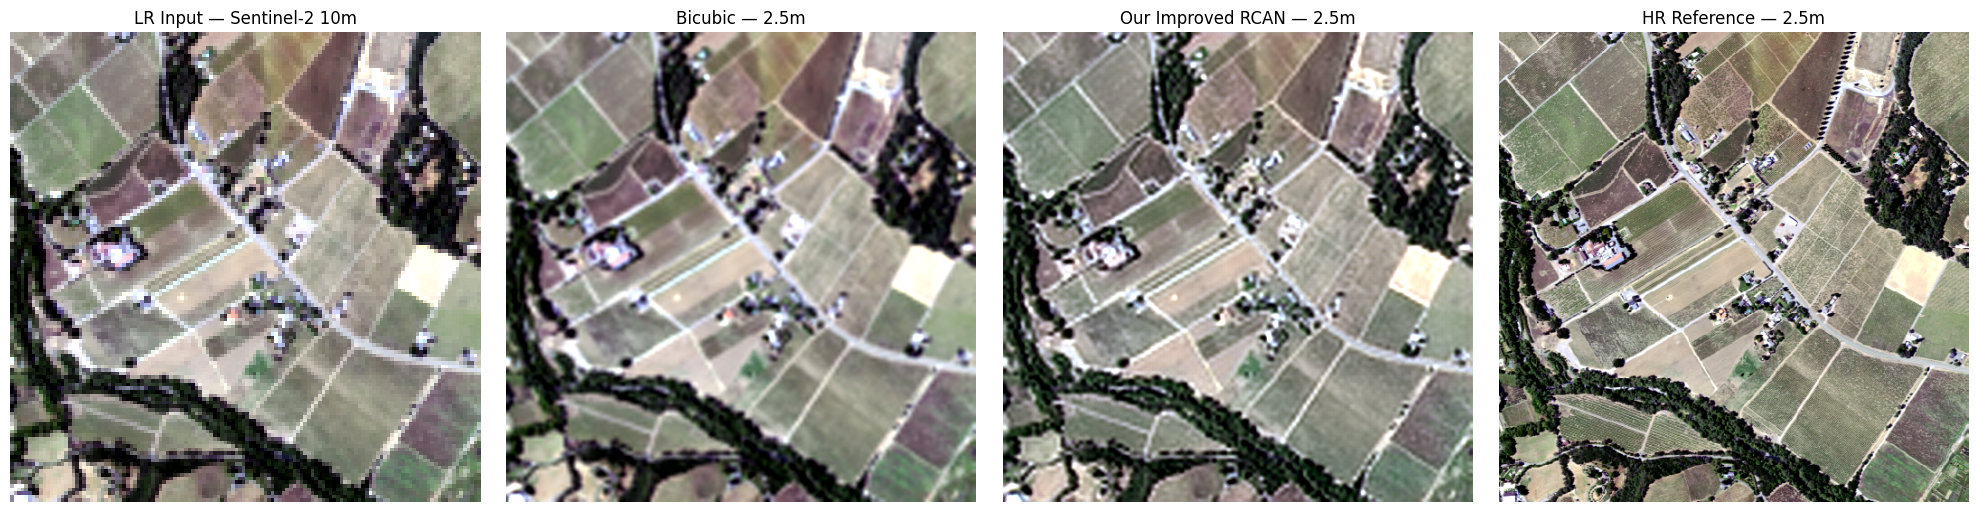

In [55]:
i = 0

lr = test_pairs[i][0]
hr = targets[i]
sr = predictions[i]

# Bicubic upsampling
lr_tensor = torch.tensor(
    lr
).unsqueeze(0).float()

bicubic = F.interpolate(
    lr_tensor,
    size=(520, 520),
    mode="bicubic",
    align_corners=False
)[0].numpy()

plt.figure(figsize=(20, 5))

# 1. Original LR
plt.subplot(1, 4, 1)
plt.imshow(stretch_rgb(lr))
plt.title("LR Input — Sentinel-2 10m")
plt.axis("off")

# 2. Bicubic
plt.subplot(1, 4, 2)
plt.imshow(stretch_rgb(bicubic))
plt.title("Bicubic — 2.5m")
plt.axis("off")

# 3. RCAN
plt.subplot(1, 4, 3)
plt.imshow(stretch_rgb(sr))
plt.title("Our Improved RCAN — 2.5m")
plt.axis("off")

# 4. HR reference
plt.subplot(1, 4, 4)
plt.imshow(stretch_rgb(hr))
plt.title("HR Reference — 2.5m")
plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
baseline_model = model

In [57]:
new_model = RCAN(
    num_blocks=12,
    channels=96
).to(device)

print("New model created")
print(
    "Parameters:",
    sum(p.numel() for p in new_model.parameters())
)

New model created
Parameters: 2776276


In [65]:
new_optimizer = torch.optim.AdamW(
    new_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    new_optimizer,
    T_max=30,
    eta_min=1e-6
)

print("Optimizer + scheduler ready")

Optimizer + scheduler ready


In [68]:
class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, prediction, target):

        difference = prediction - target

        loss = torch.sqrt(
            difference ** 2 +
            self.epsilon ** 2
        )

        return loss.mean()


loss_reconstruction = CharbonnierLoss()


def gradient_loss(pred, target):

    # Horizontal gradients
    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    # Vertical gradients
    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = torch.mean(
        torch.abs(pred_x - target_x)
    )

    loss_y = torch.mean(
        torch.abs(pred_y - target_y)
    )

    return loss_x + loss_y


def spectral_angle_loss(pred, target):

    # [B, C, H, W] → [pixels, C]
    pred = pred.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    target = target.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    # Normalize spectral vectors
    pred_norm = F.normalize(
        pred,
        p=2,
        dim=1,
        eps=1e-8
    )

    target_norm = F.normalize(
        target,
        p=2,
        dim=1,
        eps=1e-8
    )

    # Cosine similarity
    cosine = torch.sum(
        pred_norm * target_norm,
        dim=1
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7
    )

    # Spectral angle
    angle = torch.acos(cosine)

    return angle.mean()


print("All loss functions defined.")

All loss functions defined.


In [69]:
EPOCHS = 30
PATCHES_PER_EPOCH = 400

for epoch in range(EPOCHS):

    new_model.train()

    total_loss = 0
    total_recon = 0
    total_edge = 0
    total_spectral = 0

    for step in range(PATCHES_PER_EPOCH):

        idx = np.random.randint(
            len(train_pairs)
        )

        lr, hr = train_pairs[idx]

        lr_patch, hr_patch = make_patch(
            lr,
            hr,
            patch_size=32
        )

        lr_tensor = torch.tensor(
            lr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        hr_tensor = torch.tensor(
            hr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        # Forward
        prediction = new_model(lr_tensor)

        # Losses
        recon = loss_reconstruction(
            prediction,
            hr_tensor
        )

        edge = gradient_loss(
            prediction,
            hr_tensor
        )

        spectral = spectral_angle_loss(
            prediction,
            hr_tensor
        )

        # Total loss
        loss = (
            recon
            + 0.1 * edge
            + 0.01 * spectral
        )

        # Update
        new_optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            new_model.parameters(),
            max_norm=1.0
        )

        new_optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_edge += edge.item()
        total_spectral += spectral.item()

    scheduler.step()

    n = PATCHES_PER_EPOCH

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss {total_loss/n:.5f} | "
        f"Recon {total_recon/n:.5f} | "
        f"Edge {total_edge/n:.5f} | "
        f"SAM {total_spectral/n:.5f} | "
        f"LR {scheduler.get_last_lr()[0]:.2e}"
    )

Epoch 01/30 | Loss 0.08363 | Recon 0.07441 | Edge 0.08047 | SAM 0.11725 | LR 9.97e-05
Epoch 02/30 | Loss 0.05605 | Recon 0.04805 | Edge 0.07445 | SAM 0.05618 | LR 9.89e-05
Epoch 03/30 | Loss 0.05007 | Recon 0.04243 | Edge 0.07153 | SAM 0.04817 | LR 9.76e-05
Epoch 04/30 | Loss 0.04889 | Recon 0.04132 | Edge 0.07126 | SAM 0.04408 | LR 9.57e-05
Epoch 05/30 | Loss 0.04651 | Recon 0.03912 | Edge 0.06953 | SAM 0.04331 | LR 9.34e-05
Epoch 06/30 | Loss 0.04515 | Recon 0.03778 | Edge 0.06984 | SAM 0.03871 | LR 9.05e-05
Epoch 07/30 | Loss 0.04577 | Recon 0.03828 | Edge 0.07080 | SAM 0.04075 | LR 8.73e-05
Epoch 08/30 | Loss 0.04438 | Recon 0.03712 | Edge 0.06875 | SAM 0.03858 | LR 8.36e-05
Epoch 09/30 | Loss 0.04390 | Recon 0.03657 | Edge 0.06967 | SAM 0.03678 | LR 7.96e-05
Epoch 10/30 | Loss 0.04452 | Recon 0.03716 | Edge 0.07008 | SAM 0.03567 | LR 7.52e-05
Epoch 11/30 | Loss 0.04280 | Recon 0.03574 | Edge 0.06701 | SAM 0.03631 | LR 7.06e-05
Epoch 12/30 | Loss 0.04287 | Recon 0.03568 | Edge 0.06

In [70]:
new_model.eval()

new_predictions = []
test_targets = []

with torch.no_grad():

    for lr, hr in test_pairs:

        x = torch.tensor(
            lr,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        sr = new_model(x)

        new_predictions.append(
            sr.cpu().numpy()[0]
        )

        test_targets.append(hr)

new_predictions = np.stack(new_predictions)
test_targets = np.stack(test_targets)

print("Predictions:", new_predictions.shape)
print("Targets:", test_targets.shape)

Predictions: (10, 4, 520, 520)
Targets: (10, 4, 520, 520)


In [71]:
mse = np.mean(
    (new_predictions - test_targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1 / (mse + 1e-10)
)

ssim_scores = []

for i in range(len(test_targets)):

    score = ssim(
        test_targets[i].transpose(1, 2, 0),
        new_predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

new_ssim = np.mean(ssim_scores)

print()
print("========== NEW RCAN ==========")
print(f"RMSE : {rmse:.5f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {new_ssim:.4f}")


========== NEW RCAN ==========
RMSE : 0.05542
PSNR : 25.127 dB
SSIM : 0.6908


In [72]:
print("========== MODEL COMPARISON ==========")

print("\nBaseline RCAN")
print(f"RMSE : 0.05746")
print(f"PSNR : 24.813 dB")
print(f"SSIM : 0.6793")

print("\nNew RCAN")
print(f"RMSE : {rmse:.5f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {new_ssim:.4f}")

print("\nImprovement")

print(
    f"PSNR: {psnr - 24.813:+.3f} dB"
)

print(
    f"SSIM: {new_ssim - 0.6793:+.4f}"
)

print(
    f"RMSE: {rmse - 0.05746:+.5f}"
)

========== MODEL COMPARISON ==========

Baseline RCAN
RMSE : 0.05746
PSNR : 24.813 dB
SSIM : 0.6793

New RCAN
RMSE : 0.05542
PSNR : 25.127 dB
SSIM : 0.6908

Improvement
PSNR: +0.314 dB
SSIM: +0.0115
RMSE: -0.00204


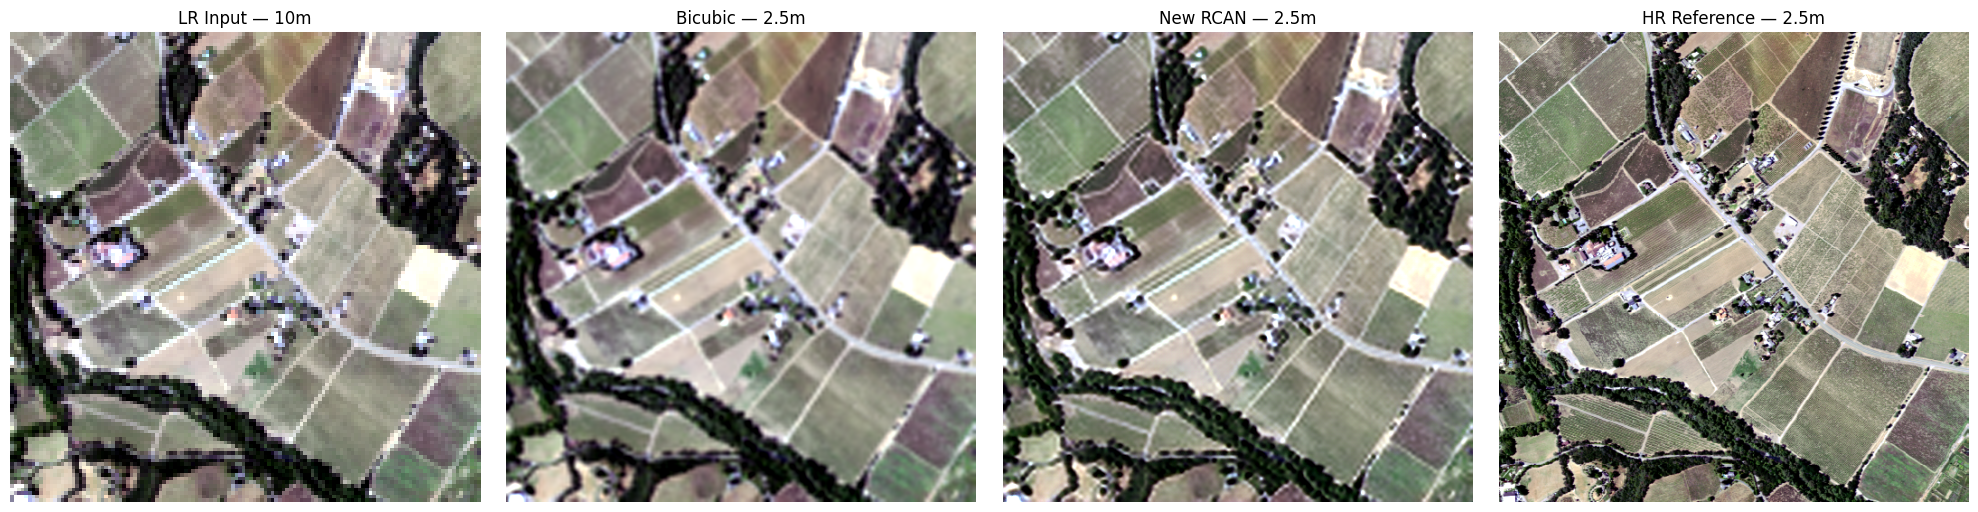

In [73]:
i = 0

lr = test_pairs[i][0]
hr = test_targets[i]
sr = new_predictions[i]

lr_tensor = torch.tensor(
    lr
).unsqueeze(0).float()

bicubic = F.interpolate(
    lr_tensor,
    size=(520, 520),
    mode="bicubic",
    align_corners=False
)[0].numpy()

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(stretch_rgb(lr))
plt.title("LR Input — 10m")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(stretch_rgb(bicubic))
plt.title("Bicubic — 2.5m")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(stretch_rgb(sr))
plt.title("New RCAN — 2.5m")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(stretch_rgb(hr))
plt.title("HR Reference — 2.5m")
plt.axis("off")

plt.tight_layout()
plt.show()